In [ ]:
pip install sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.1 MB/s eta 0:00:00
  Created wheel for sentence-transformers: filename=sentence_transformers-2.2.2-py3-none-any.whl size=125923 sha256=5e796e80636fa391128b6d8a982462c72a3a73362c631cbdcf7575e060dbb81b
  Stored in directory: /root/.cache/pip/wheels/62/f2/10/1e606fd5f02395388f74e7462910fe851042f97238cbbd902f
Successfully built sentence-transformers


In [ ]:
#Importing Libraries
import pandas as pd #to read data
import numpy as np #to perform mathematical operartions
import re #for string formatting
import nltk #for text pre processing
import matplotlib.pyplot as plt #to plot graphs
from sentence_transformers import SentenceTransformer #for generating embeddings
import tensorflow as tf #to create DNN
import keras #to make API calls for DNN
from sklearn.model_selection import train_test_split #to split dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #to evaluate models
import torch #for tensors
import random
#to reproduce results
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
#reading data
pd.set_option("display.width",1000)
pd.set_option('display.expand_frame_repr', False)
df_train = pd.read_csv("/content/spanish/Hope_spanish_train.csv",index_col = 0)#training script
df_dev = pd.read_csv("/content/spanish/Hope_spanish_dev.csv",index_col = 0)#development script
df_test = pd.read_csv("/content/spanish/hope_spanish_test_without_labels.csv",index_col = 0)

In [ ]:
df_train

,text,category
id,,
1409416455200858113,"🏳️‍🌈Todas ellas coinciden, además, en que la p...",HS
1409453454372884480,Que impotencia y que rabia! Gracias por compa...,HS
1409390524369358849,Cada 28 de Junio me levanto escuchando Born Th...,HS
1409159127532818432,"El #28J representa a mi entender y demuestra, ...",HS
1416871411965104129,Gran gesto de por emitir ahora en pleno prime ...,HS
...,...,...
1411744950740455434,Imagínate tener un hijo que crees que es norma...,NHS
1415313028556500997,y que creí que la comunidad lgbti lleva mucho...,NHS
1410748329873481736,🚨UEFA LE DICE NO A LOS COLORES DEL #LGTBI 🚨La ...,NHS


In [ ]:
df_dev

,text,category
id,,
1417628745574268931,#justiciaparasamuelDejar claro q sigo orgullo...,HS
1409450587146657792,"Me he visto derrotada muchas veces, he necesit...",HS
1412108239756480515,Hacía tiempo que no notaba tanta indignación e...,HS
1409016896842878977,"Por eso en este mes del orgullo LGBT, instamos...",HS
1412147894652653571,El grito de hoy no es un grito #LGTBI. Es un g...,HS
...,...,...
1414579286665830406,En Madrid tambien hay agresiones homofobas. Q...,NHS
1411420471850147847,"Es que la violencia es humana, no es de hombr...",NHS
1410869101417930755,Gracias por anular con tu súper ley del grupo...,NHS


In [ ]:
df_test

,text
id,
1323640726912225282,"Si no apoyas el avance de ley trans, eres tran..."
1557342324438581249,ALAN TURING. Terminó con su propia vida el 7 d...
1323625645549694982,Pues la ley Trans es una lucha más y un derech...
1333017189708918784,"si es una tia trans, es una tia, porque si tie..."
1318159969099808769,DEUDA DE LA DEMOCRACIA. La población trans-tra...
...,...
1322266666668040198,🙌 por Jorge y por todos los niños y niñas tran...
1329740438463504385,#MemoriaTrans #LeyTransEstatal YA #DerechosTra...
1325135611829874690,"Y también Sarah McBride, una afamada activista..."


In [ ]:
df = pd.concat([df_train,df_dev],axis = 0 )
category_counts = df['category'].value_counts()
category_counts

NHS    821
HS     791
Name: category, dtype: int64

In [ ]:
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
pip install pyspellchecker

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 12.4 MB/s eta 0:00:00


In [ ]:
import string
import math
from spellchecker import SpellChecker
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
# creating functions for each task
def split_attached_words(text):
    #attached words look like #PeaceForUkraine
    text = text.replace("#", "")
    pattern = r'([A-Z][a-z]+|[a-z]+)(?=[A-Z])'
    split_text = re.sub(pattern, r'\1 ', text)

    return split_text
#expanding contractions
def decontracted(text):
    # specific
    text = re.sub(r"won\'t", "will not", text)
    text = re.sub(r"can\'t", "can not", text)
    # general
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    return text

def preprocess(text):
#lower case the data (text):
    text = text.lower()
#remove numbers and words containing numbers
    text = re.sub('\w*\d\w*','', text)
# Remove HTML tags
    soup = BeautifulSoup(text, "html.parser")
    text_without_html = soup.get_text(separator=" ")
# Remove other links (e.g., URLs)
    text = re.sub(r'http\S+|www.\S+', '', text_without_html)
#remove punctuations
    translator = str.maketrans("", "", string.punctuation)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.translate(translator)
#stopwords removal
    stop_words = set(stopwords.words('english')) # you can download the stopwords of the language you are working on
    tokens = word_tokenize(text)
    filtered_tokens = [token for token in tokens if token.lower() not in stop_words]
    text = ' '.join(filtered_tokens)
    return text
#stemming of the text
def lemmatize(text):
    #You can use snowball stemmer for different languages like hindi
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    text = " ".join(lemmatized_tokens)
    return text
def substitute_emojis(text, replacement="[EMOJI]"):
    # Define the emoji pattern using Unicode blocks
    emoji_pattern = re.compile("[\U0001F600-\U0001F64F\u2600-\u26FF\u2700-\u27BF\U0001F300-\U0001F5FF"
                               "\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]+", flags=re.UNICODE)

    # Substitute emojis with the replacement text
    text = emoji_pattern.sub(replacement, text)

    return text

In [ ]:
# Applying function on data to clean the text
df["text"] = df["text"].apply(split_attached_words)
df["text"] = df["text"].apply(decontracted)
df["text"] = df["text"].apply(preprocess)
df["text"] = df["text"].apply(substitute_emojis)
df["text"] = df["text"].apply(lemmatize)

<ipython-input-13-d14a398dbf9f>:38: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")


In [ ]:
# Applying function on data to clean the text
df_test["text"] = df_test["text"].apply(split_attached_words)
df_test["text"] = df_test["text"].apply(decontracted)
df_test["text"] = df_test["text"].apply(preprocess)
df_test["text"] = df_test["text"].apply(substitute_emojis)
df_test["text"] = df_test["text"].apply(lemmatize)

<ipython-input-13-d14a398dbf9f>:38: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")


In [ ]:
df

,text,category
id,,
1409416455200858113,toda ellas coinciden además en que la priorida...,HS
1409453454372884480,que impotencia que rabia gracias por compartir...,HS
1409390524369358849,cada de junio levanto escuchando born way sigu...,HS
1409159127532818432,el representa mi entender demuestra que la uto...,HS
1416871411965104129,gran gesto de por emitir ahora en pleno prime ...,HS
...,...,...
1414579286665830406,en madrid tambien hay agresiones homofobas que...,NHS
1411420471850147847,e que la violencia e humana e de hombre mujere...,NHS
1410869101417930755,gracias por anular con tu súper ley del grupo ...,NHS


In [ ]:
df_test

,text
id,
1323640726912225282,si apoyas el avance de ley trans eres transfob...
1557342324438581249,alan turing terminó con su propia vida el de j...
1323625645549694982,pues la ley trans e una lucha más un derecho m...
1333017189708918784,si e una tia trans e una tia porque si tiene s...
1318159969099808769,deuda de la democracia la población transtrava...
...,...
1322266666668040198,por jorge por todos los niños niñas trans está...
1329740438463504385,memoria trans ley trans estatal ya derechos tr...
1325135611829874690,también sarah mc bride una afamada activista p...


In [ ]:
def remove_extra_whitespaces(text):
  # Replace all consecutive whitespaces with a single space.
  text = re.sub(r'\s+', ' ', text)

  # Remove leading and trailing whitespaces.
  text = text.strip()

  return text
df['text'] = df['text'].apply(remove_extra_whitespaces)
df_test['text'] = df_test['text'].apply(remove_extra_whitespaces)

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
labels = list(df["category"])
labels_reshaped = [label for label in labels]
encoder.fit(labels_reshaped)
Target= encoder.transform(labels_reshaped) # this will remain target for each of the classification task

In [ ]:
X_train, X_test, y_train = df['text'],df_test['text'],Target

In [ ]:
from scipy import sparse as sp_sparse
# Dictionary of all words from train corpus with their counts.
words_counts = {}
for comments in X_train:
    for word in comments.split():
        if word not in words_counts:
            words_counts[word] = 1
        words_counts[word] += 1

DICT_SIZE = 10000
POPULAR_WORDS = sorted(words_counts, key=words_counts.get, reverse=True)[:DICT_SIZE]
WORDS_TO_INDEX = {key: rank for rank, key in enumerate(POPULAR_WORDS, 0)}
INDEX_TO_WORDS = {index:word for word, index in WORDS_TO_INDEX.items()}
ALL_WORDS = WORDS_TO_INDEX.keys()

In [ ]:
def my_bag_of_words(text, words_to_index, dict_size):
    """
        text: a string
        dict_size: size of the dictionary

        return a vector which is a bag-of-words representation of 'text'
    """
    result_vector = np.zeros(dict_size)
    for word in text.split(' '):
        if word in words_to_index:
            result_vector[words_to_index[word]] +=1
    return result_vector

X_train_mybag = sp_sparse.vstack([sp_sparse.csr_matrix(my_bag_of_words(text, WORDS_TO_INDEX, DICT_SIZE)) for text in X_train])
X_test_mybag = sp_sparse.vstack([sp_sparse.csr_matrix(my_bag_of_words(text, WORDS_TO_INDEX, DICT_SIZE)) for text in X_test])
print('X_train shape ', X_train_mybag.shape, '\nX_val shape ', X_test_mybag.shape)

X_train shape  (1612, 10000) 
X_val shape  (547, 10000)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
def tfidf_features(X_train, X_test):
    """
        X_train, X_test — samples
        return TF-IDF vectorized representation of each sample and vocabulary
    """
    # Create TF-IDF vectorizer with a proper parameters choice
    tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_df=0.9, min_df=5)#, token_pattern='(\S+)')
    # Fit the vectorizer on the train set
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
    # Transform the train, test set and return the result
    X_test_tfidf = tfidf_vectorizer.transform(X_test)

    return X_train_tfidf,  X_test_tfidf, tfidf_vectorizer.vocabulary_,tfidf_vectorizer.get_feature_names_out()

X_train_tfidf, X_test_tfidf, tfidf_vocab,feature_names_tfidf = tfidf_features(X_train, X_test)
tfidf_reversed_vocab = {i:word for word,i in tfidf_vocab.items()}

In [ ]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 533.5/533.5 kB 6.8 MB/s eta 0:00:00


In [ ]:
import shap
import numpy as np
from scipy import sparse as sp

def explainable_AI(model, X_train, feature_names, X_test, ShapExplainer, flag=True):
    explainer = ShapExplainer(model, X_train, feature_names=feature_names)
    shap_values = explainer.shap_values(X_test)

    # Convert shap_values to a 2D matrix
    shap_values_matrix = np.vstack(shap_values)

    # Convert sparse matrix to dense matrix for shap.summary_plot
    X_test_dense = X_test.toarray() if sp.issparse(X_test) else X_test

    print("Summary plot as a whole:")
    shap.summary_plot(shap_values_matrix, X_test_dense, feature_names=feature_names, class_names=['NHS', 'HS'])
    print()
    shap.summary_plot(shap_values_matrix, X_test_dense, feature_names=feature_names, class_names=['NHS', 'HS'],plot_type='bar')
    print()

    return explainer, shap_values

In [ ]:
df_test_labels = pd.read_csv("/content/spanish/hope_spanish_test_with_labels.csv",index_col = 0)
y_true = df_test_labels['category']
# Assuming df_test_labels contains the true labels for the test set
# Convert the labels in y_true to numeric values if needed
# For example, if 'HS' is 1 and 'NHS' is 0
y_true_numeric = encoder.transform(y_true)
y_true_numeric

array([0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,

In [ ]:
#Importing Machine Learning Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB

# Classifier Models

# Random Forest Classifier

In [ ]:
model = RandomForestClassifier().fit(X_train_tfidf, y_train)
y_test_predicted_labels_mybag = model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_mybag)
y_test = [label for label in decoded_y_test]

In [ ]:
y_test_predicted_labels_mybag

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
np.unique(y_test)

array(['HS', 'NHS'], dtype='<U3')

In [ ]:
df_test['label'] = y_test

In [ ]:
df_test['label']

id
1323640726912225282    NHS
1557342324438581249    NHS
1323625645549694982    NHS
1333017189708918784    NHS
1318159969099808769    NHS
                      ... 
1322266666668040198    NHS
1329740438463504385    NHS
1325135611829874690    NHS
1327806352966692865    NHS
1332534831159406593    NHS
Name: label, Length: 547, dtype: object

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.5320
Precision: 0.4908
Recall: 0.9717
F1-score: 0.6522


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[ 51 249]
 [  7 240]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.17      0.28       300
           1       0.49      0.97      0.65       247

    accuracy                           0.53       547
   macro avg       0.69      0.57      0.47       547
weighted avg       0.70      0.53      0.45       547



# Logistic Regression

In [ ]:
# Train Logistic Regression model
logreg_model_tfidf = LogisticRegression(random_state=42)
logreg_model_tfidf.fit(X_train_tfidf, y_train)
y_test_predicted_labels_logreg_tfidf = logreg_model_tfidf.predict(X_test_tfidf)

In [ ]:
# Train Logistic Regression model
logreg_model_bow = LogisticRegression(random_state=42)
logreg_model_bow.fit(X_train_mybag, y_train)
y_test_predicted_labels_logreg_mybag = logreg_model_bow.predict(X_test_mybag)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_logreg_tfidf)
y_test_logreg_tfidf = [label for label in decoded_y_test_tfidf]

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_logreg_mybag)
y_test_logreg_mybag = [label for label in decoded_y_test_mybag]

In [ ]:
y_test_predicted_labels_logreg_tfidf

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
y_test_predicted_labels_logreg_mybag

array([1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
np.unique(y_test_logreg_tfidf)

array(['HS', 'NHS'], dtype='<U3')

In [ ]:
np.unique(y_test_logreg_mybag)

array(['HS', 'NHS'], dtype='<U3')

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_logreg_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_logreg_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Accuracy: 0.5740
Precision: 0.5161
Recall: 0.9109
F1-score: 0.6589
Confusion Matrix:
[[ 89 211]
 [ 22 225]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.30      0.43       300
           1       0.52      0.91      0.66       247

    accuracy                           0.57       547
   macro avg       0.66      0.60      0.55       547
weighted avg       0.67      0.57      0.54       547



Summary plot as a whole:


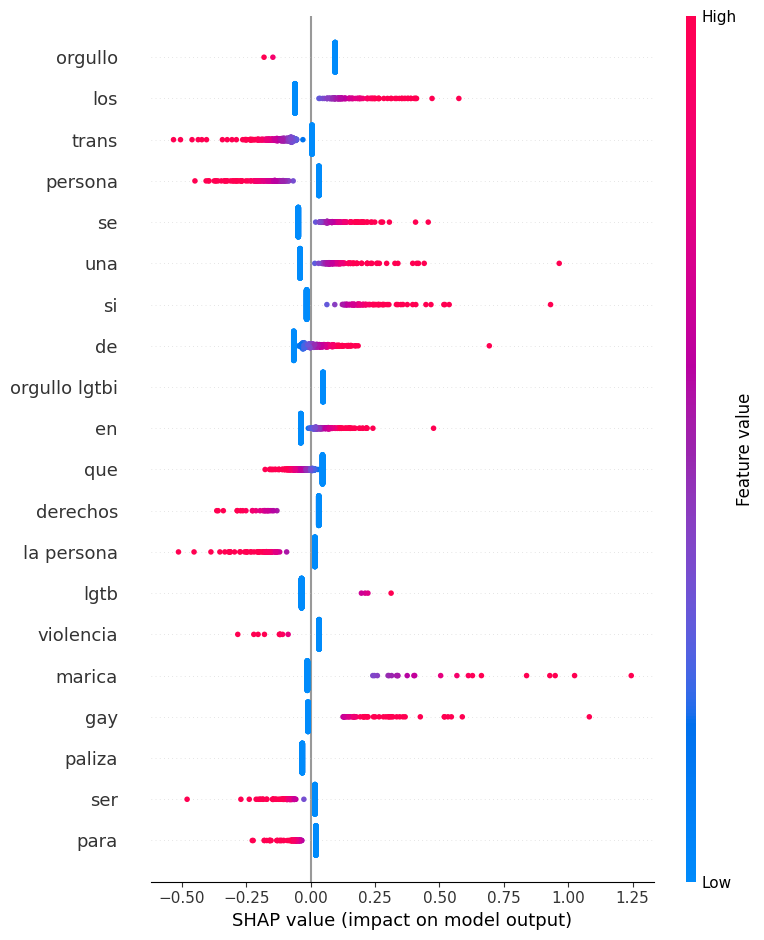

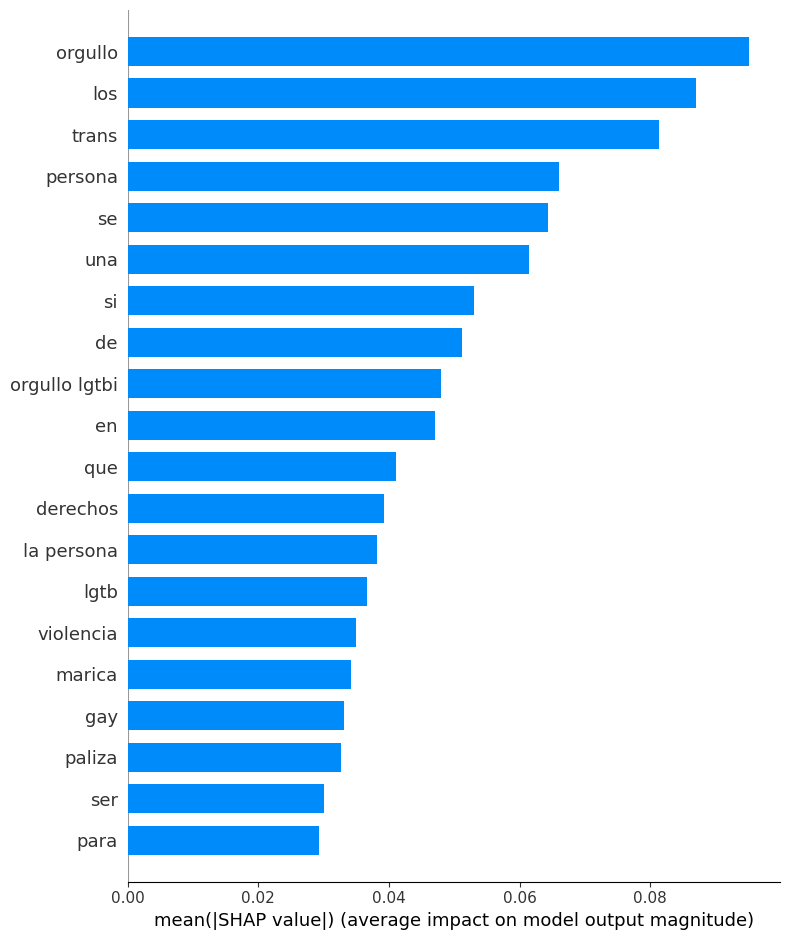

In [ ]:
explainer_logreg_tfidf, shap_values_logreg_tfidf = explainable_AI(logreg_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_logreg_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_logreg_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_logreg_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_logreg_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_logreg_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_logreg_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Accuracy: 0.5594
Precision: 0.5067
Recall: 0.9150
F1-score: 0.6522
Confusion Matrix:
[[ 80 220]
 [ 21 226]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.27      0.40       300
           1       0.51      0.91      0.65       247

    accuracy                           0.56       547
   macro avg       0.65      0.59      0.53       547
weighted avg       0.66      0.56      0.51       547



Summary plot as a whole:


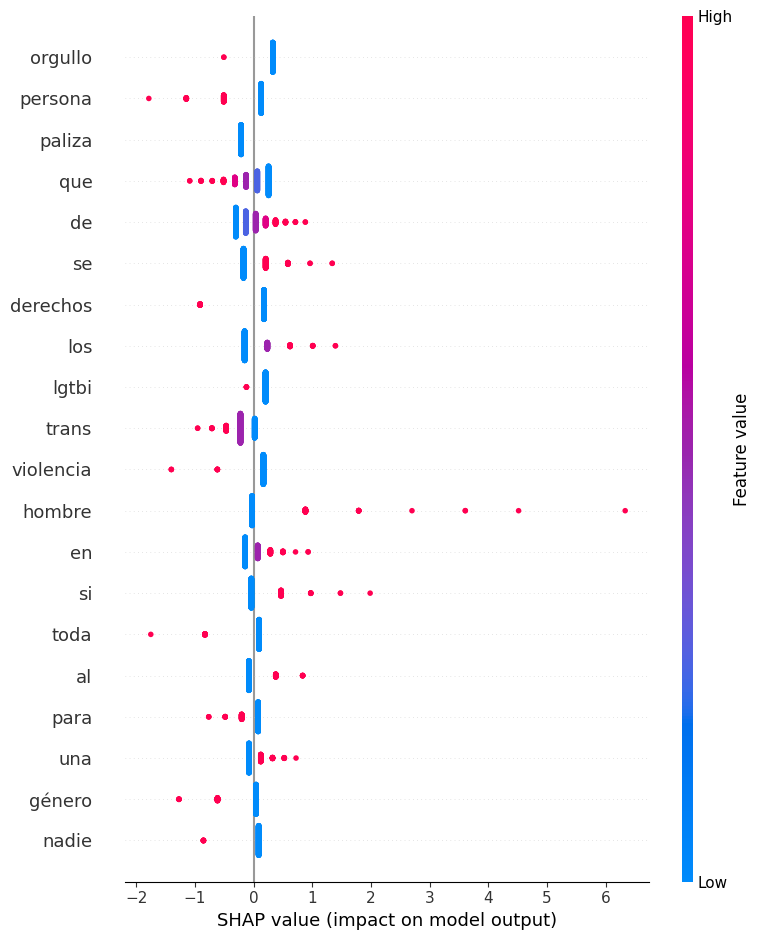

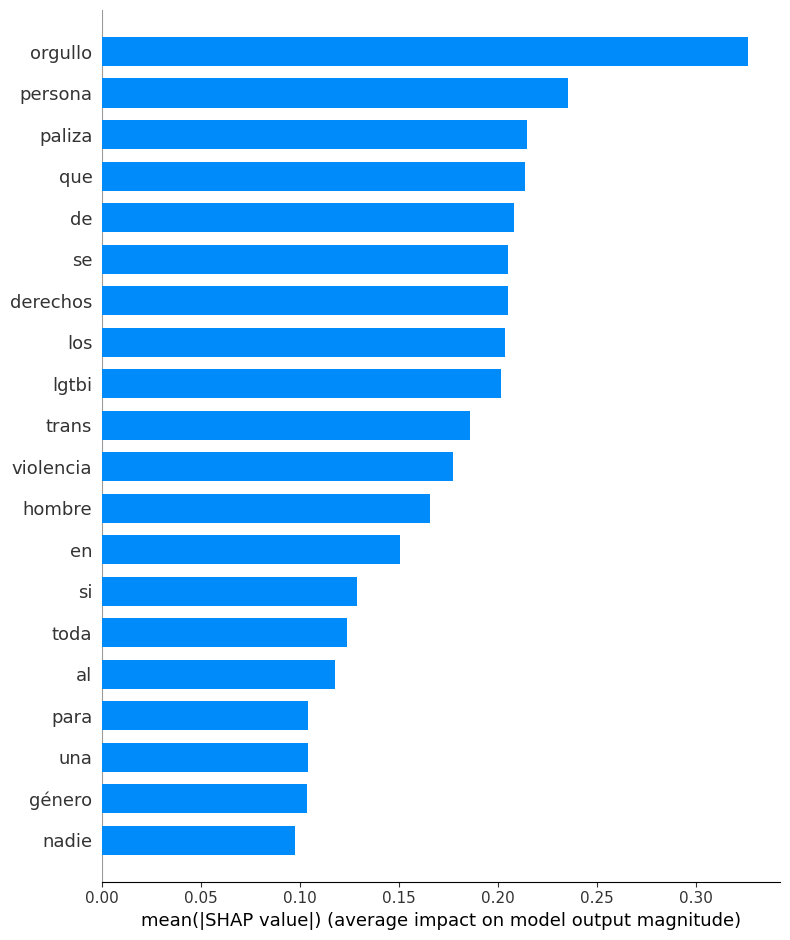

In [ ]:
explainer_logreg_bow, shap_values_logreg_bow = explainable_AI(logreg_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

# Linear SVC

In [ ]:
linear_svc_model = LinearSVC(random_state=42)
linear_svc_model.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_svc = linear_svc_model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_svc)
y_test_svc = [label for label in decoded_y_test]
y_test_predicted_labels_svc

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
np.unique(y_test_svc)

array(['HS', 'NHS'], dtype='<U3')

In [ ]:
df_test['label'] = y_test_svc
df_test['label']

id
1323640726912225282    NHS
1557342324438581249    NHS
1323625645549694982    NHS
1333017189708918784    NHS
1318159969099808769     HS
                      ... 
1322266666668040198    NHS
1329740438463504385     HS
1325135611829874690     HS
1327806352966692865    NHS
1332534831159406593    NHS
Name: label, Length: 547, dtype: object

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_svc)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_svc, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_svc, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_svc, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.5795
Precision: 0.5208
Recall: 0.8623
F1-score: 0.6494


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_svc)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_svc)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[104 196]
 [ 34 213]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.35      0.47       300
           1       0.52      0.86      0.65       247

    accuracy                           0.58       547
   macro avg       0.64      0.60      0.56       547
weighted avg       0.65      0.58      0.55       547



# Multinomial Naive Bayes

In [ ]:
# Train Multinomial Naive Bayes model
mnb_model = MultinomialNB()
mnb_model.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_mnb = mnb_model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_mnb)
y_test_mnb = [label for label in decoded_y_test]
y_test_predicted_labels_mnb

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_mnb)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_mnb, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_mnb, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_mnb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.5759
Precision: 0.5189
Recall: 0.8340
F1-score: 0.6398


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_mnb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_mnb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[109 191]
 [ 41 206]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.36      0.48       300
           1       0.52      0.83      0.64       247

    accuracy                           0.58       547
   macro avg       0.62      0.60      0.56       547
weighted avg       0.63      0.58      0.55       547



# XG Boost

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert data to DMatrix format used by XGBoost
dtrain = xgb.DMatrix(X_train_tfidf, label=y_train)
dtest = xgb.DMatrix(X_test_tfidf)

# Set XGBoost parameters (you may adjust these based on your needs)
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 4,
    'learning_rate': 0.01,
    'n_estimators': 50,
    'seed': 42
}

# Train XGBoost model
xgb_model = xgb.train(params, dtrain)

# Predict labels for the test set
y_test_predicted_labels_xgb = xgb_model.predict(dtest)
y_test_predicted_labels_xgb = [1 if pred > 0.5 else 0 for pred in y_test_predicted_labels_xgb]

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [18:36:48] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_xgb)
y_test_xgb = [label for label in decoded_y_test]
y_test_predicted_labels_xgb

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_xgb)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_xgb, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_xgb, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_xgb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.4589
Precision: 0.4549
Recall: 1.0000
F1-score: 0.6253


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_xgb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_xgb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[  4 296]
 [  0 247]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.03       300
           1       0.45      1.00      0.63       247

    accuracy                           0.46       547
   macro avg       0.73      0.51      0.33       547
weighted avg       0.75      0.46      0.30       547



# Ada Boost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train AdaBoost model
adaboost_model = AdaBoostClassifier(random_state=42)
adaboost_model.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_adaboost = adaboost_model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_adaboost)
y_test_adaboost = [label for label in decoded_y_test]
y_test_predicted_labels_adaboost

array([1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_adaboost)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_adaboost, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_adaboost, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_adaboost, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.5174
Precision: 0.4812
Recall: 0.8785
F1-score: 0.6218


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_adaboost)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_adaboost)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[ 66 234]
 [ 30 217]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.22      0.33       300
           1       0.48      0.88      0.62       247

    accuracy                           0.52       547
   macro avg       0.58      0.55      0.48       547
weighted avg       0.59      0.52      0.46       547



# Decision Tree

In [ ]:
# Train Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_tree = decision_tree_model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_tree)
y_test_tree = [label for label in decoded_y_test]
y_test_predicted_labels_tree

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_tree)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_tree, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_tree, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_tree, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.5576
Precision: 0.5062
Recall: 0.8300
F1-score: 0.6288


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_tree)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_tree)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[100 200]
 [ 42 205]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.33      0.45       300
           1       0.51      0.83      0.63       247

    accuracy                           0.56       547
   macro avg       0.61      0.58      0.54       547
weighted avg       0.61      0.56      0.53       547



# Gradient Boosting

In [ ]:
# Train Gradient Boosting model
gradient_boosting_model = GradientBoostingClassifier(random_state=42)
gradient_boosting_model.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_gb = gradient_boosting_model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_gb)
y_test_gb = [label for label in decoded_y_test]
y_test_predicted_labels_gb

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_gb)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_gb, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_gb, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_gb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.5247
Precision: 0.4867
Recall: 0.9595
F1-score: 0.6458


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_gb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_gb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[ 50 250]
 [ 10 237]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.17      0.28       300
           1       0.49      0.96      0.65       247

    accuracy                           0.52       547
   macro avg       0.66      0.56      0.46       547
weighted avg       0.68      0.52      0.44       547



# SVM

In [ ]:
from sklearn.svm import SVC
svm_model = SVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_svm = svm_model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_svm)
y_test_svm = [label for label in decoded_y_test]
y_test_predicted_labels_svm

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_svm)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_svm, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_svm, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_svm, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.5667
Precision: 0.5115
Recall: 0.9028
F1-score: 0.6530


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_svm)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_svm)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[ 87 213]
 [ 24 223]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.29      0.42       300
           1       0.51      0.90      0.65       247

    accuracy                           0.57       547
   macro avg       0.65      0.60      0.54       547
weighted avg       0.66      0.57      0.53       547



# Ridge Classifier

In [ ]:
from sklearn.linear_model import RidgeClassifier

# Train Ridge Classifier model
ridge_classifier_model_bow = RidgeClassifier(random_state=42)
ridge_classifier_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_ridge_mybag = ridge_classifier_model_bow.predict(X_test_mybag)

In [ ]:
from sklearn.linear_model import RidgeClassifier

# Train Ridge Classifier model
ridge_classifier_model_tfidf = RidgeClassifier(random_state=42)
ridge_classifier_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_ridge_tfidf = ridge_classifier_model_tfidf.predict(X_test_tfidf)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_ridge_mybag)
y_test_ridge_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_ridge_mybag

array([1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_ridge_tfidf)
y_test_ridge_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_ridge_tfidf

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_ridge_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_ridge_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_ridge_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_ridge_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_ridge_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_ridge_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.5594
Precision: 0.5076
Recall: 0.8097
F1-score: 0.6240
Confusion Matrix:
[[106 194]
 [ 47 200]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.35      0.47       300
           1       0.51      0.81      0.62       247

    accuracy                           0.56       547
   macro avg       0.60      0.58      0.55       547
weighted avg       0.61      0.56      0.54       547



Summary plot as a whole:


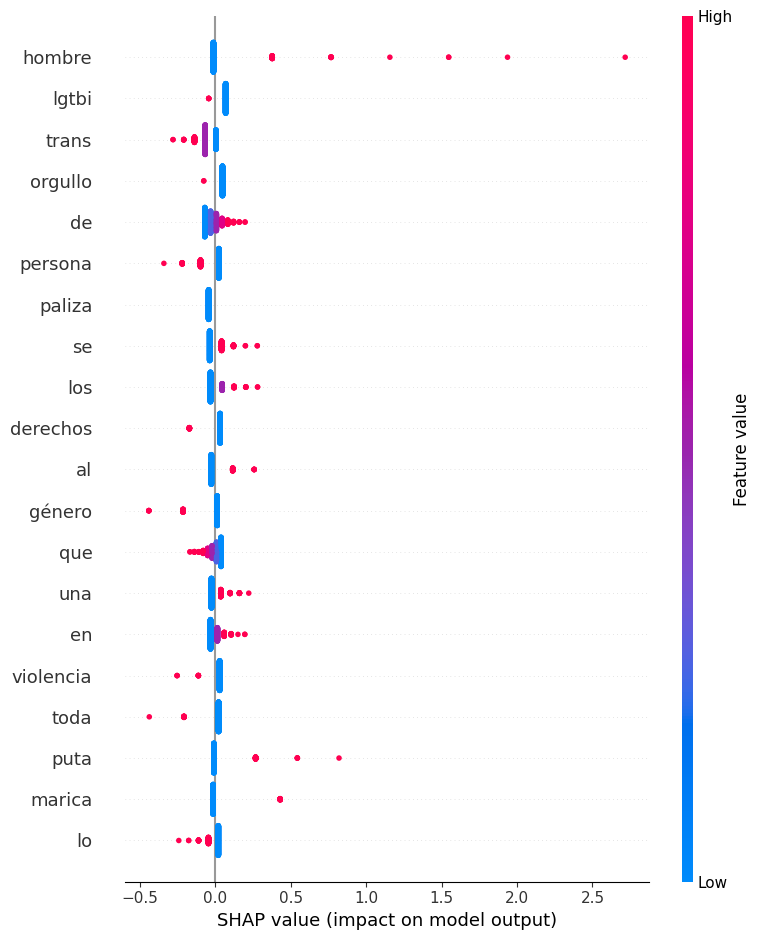

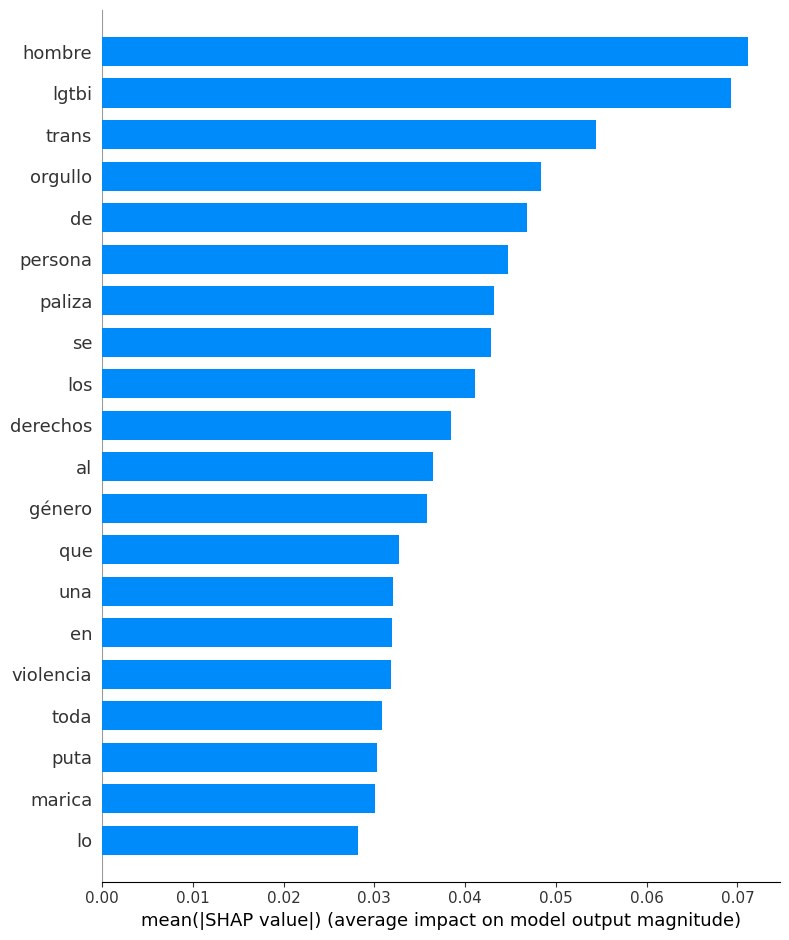

In [ ]:
explainer_ridge_bow, shap_values_ridge_bow = explainable_AI(ridge_classifier_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_ridge_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_ridge_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.5850
Precision: 0.5240
Recall: 0.8826
F1-score: 0.6576
Confusion Matrix:
[[102 198]
 [ 29 218]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.34      0.47       300
           1       0.52      0.88      0.66       247

    accuracy                           0.59       547
   macro avg       0.65      0.61      0.57       547
weighted avg       0.66      0.59      0.56       547



Summary plot as a whole:


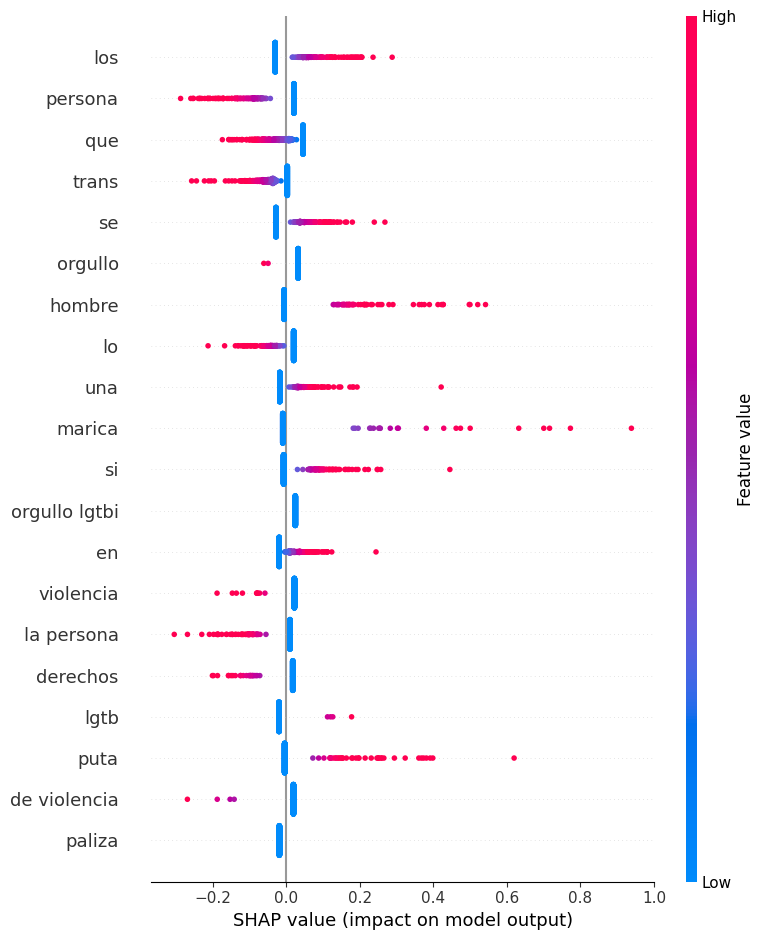

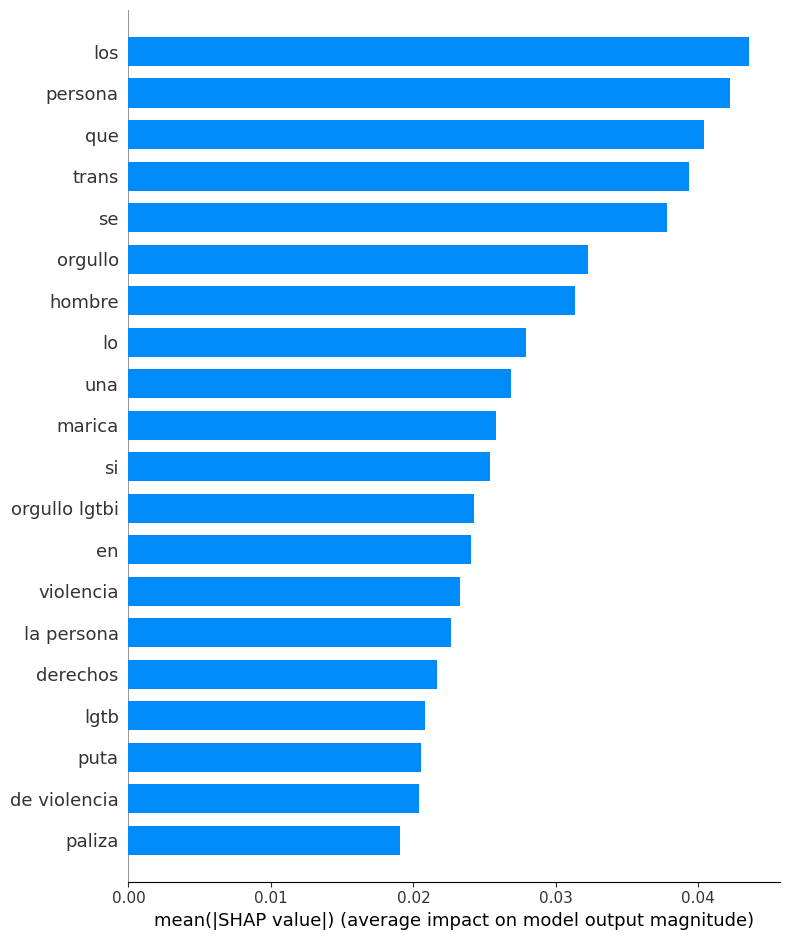

In [ ]:
explainer_ridge_tfidf, shap_values_ridge_tfidf = explainable_AI(ridge_classifier_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Perceptron Classifier

In [ ]:
from sklearn.linear_model import Perceptron

# Train Perceptron model
perceptron_model_bow = Perceptron(random_state=42)
perceptron_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_perceptron_mybag = perceptron_model_bow.predict(X_test_mybag)


In [ ]:
# Train Perceptron model
perceptron_model_tfidf = Perceptron(random_state=42)
perceptron_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_perceptron_tfidf = perceptron_model_tfidf.predict(X_test_tfidf)


In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_perceptron_mybag)
y_test_perceptron_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_perceptron_mybag

array([1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_perceptron_tfidf)
y_test_perceptron_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_perceptron_tfidf

array([1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_perceptron_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_perceptron_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.5832
Precision: 0.5262
Recall: 0.7733
F1-score: 0.6262
Confusion Matrix:
[[128 172]
 [ 56 191]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.43      0.53       300
           1       0.53      0.77      0.63       247

    accuracy                           0.58       547
   macro avg       0.61      0.60      0.58       547
weighted avg       0.62      0.58      0.57       547



Summary plot as a whole:


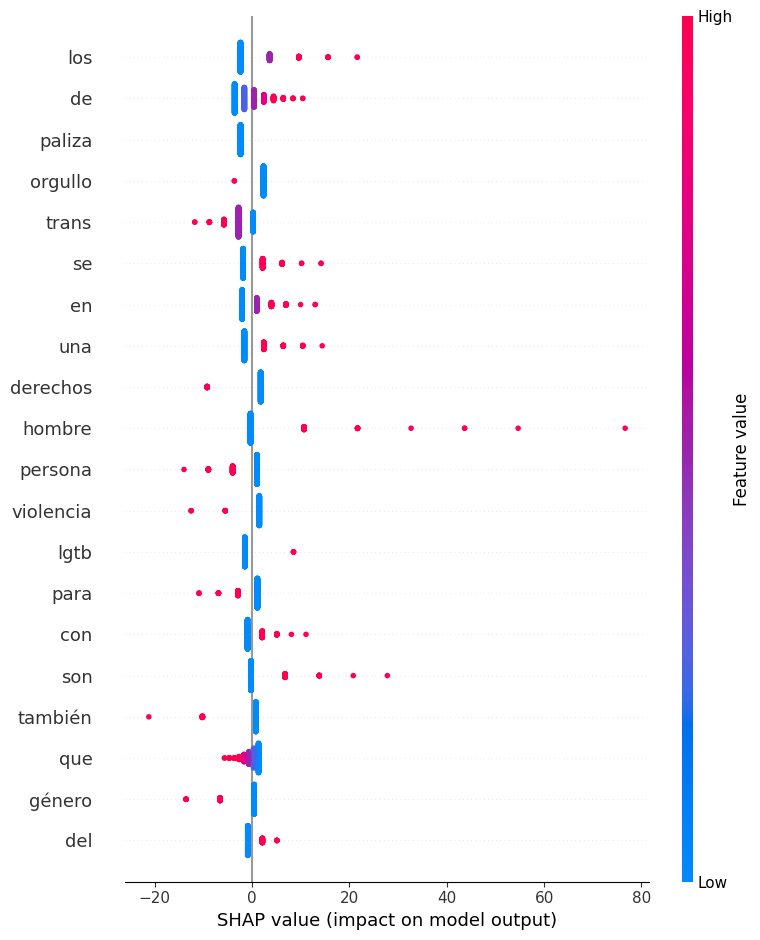

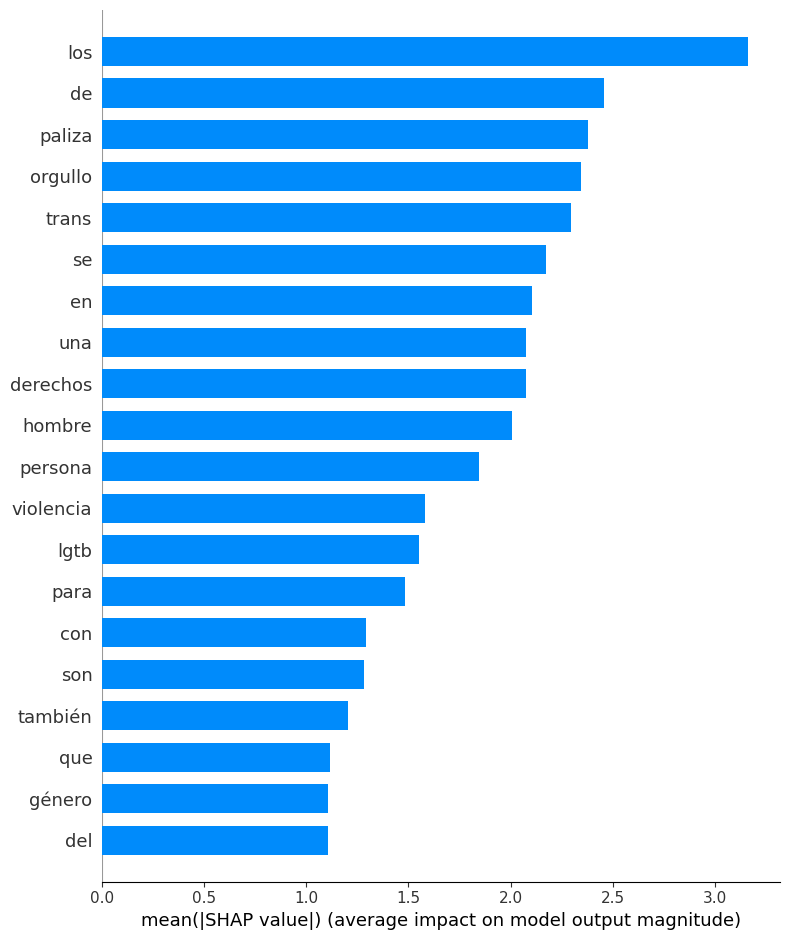

In [ ]:
explainer_perceptron_bow, shap_values_perceptron_bow = explainable_AI(perceptron_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_perceptron_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_perceptron_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF results:

Accuracy: 0.5612
Precision: 0.5093
Recall: 0.7733
F1-score: 0.6141
Confusion Matrix:
[[116 184]
 [ 56 191]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.39      0.49       300
           1       0.51      0.77      0.61       247

    accuracy                           0.56       547
   macro avg       0.59      0.58      0.55       547
weighted avg       0.60      0.56      0.55       547



Summary plot as a whole:


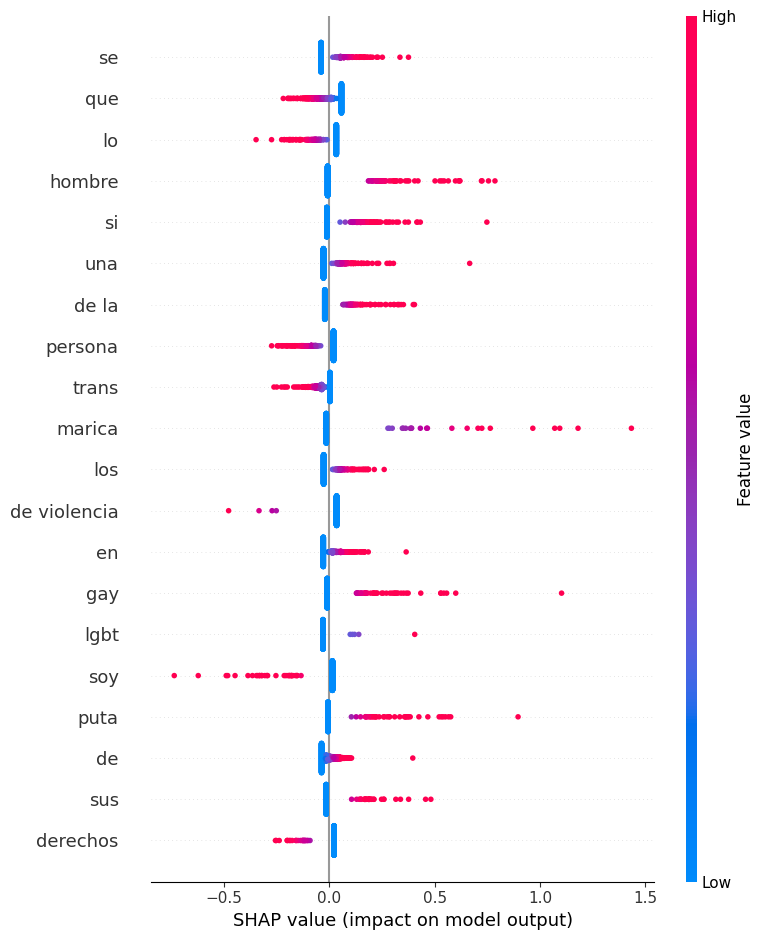

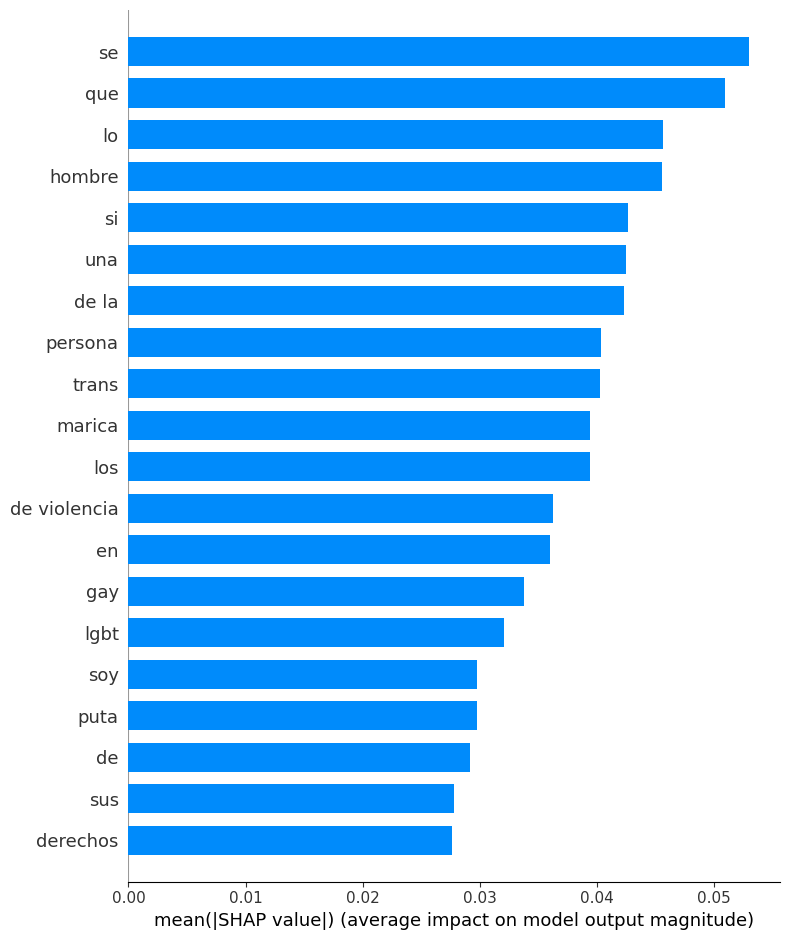

In [ ]:
explainer_perceptron_tfidf, shap_values_perceptron_tfidf = explainable_AI(perceptron_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# SGD classifier

In [ ]:
from sklearn.linear_model import SGDClassifier

# Train SGD Classifier model
sgd_classifier_model_bow = SGDClassifier(random_state=42)
sgd_classifier_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_sgd_mybag = sgd_classifier_model_bow.predict(X_test_mybag)


In [ ]:
# Train SGD Classifier model
sgd_classifier_model_tfidf = SGDClassifier(random_state=42)
sgd_classifier_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_sgd_tfidf = sgd_classifier_model_tfidf.predict(X_test_tfidf)


In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_sgd_mybag)
y_test_sgd_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_sgd_mybag

array([1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_sgd_tfidf)
y_test_sgd_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_sgd_tfidf

array([1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_sgd_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_sgd_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_sgd_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_sgd_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_sgd_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_sgd_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.5905
Precision: 0.5317
Recall: 0.7814
F1-score: 0.6328
Confusion Matrix:
[[130 170]
 [ 54 193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.43      0.54       300
           1       0.53      0.78      0.63       247

    accuracy                           0.59       547
   macro avg       0.62      0.61      0.58       547
weighted avg       0.63      0.59      0.58       547



Summary plot as a whole:


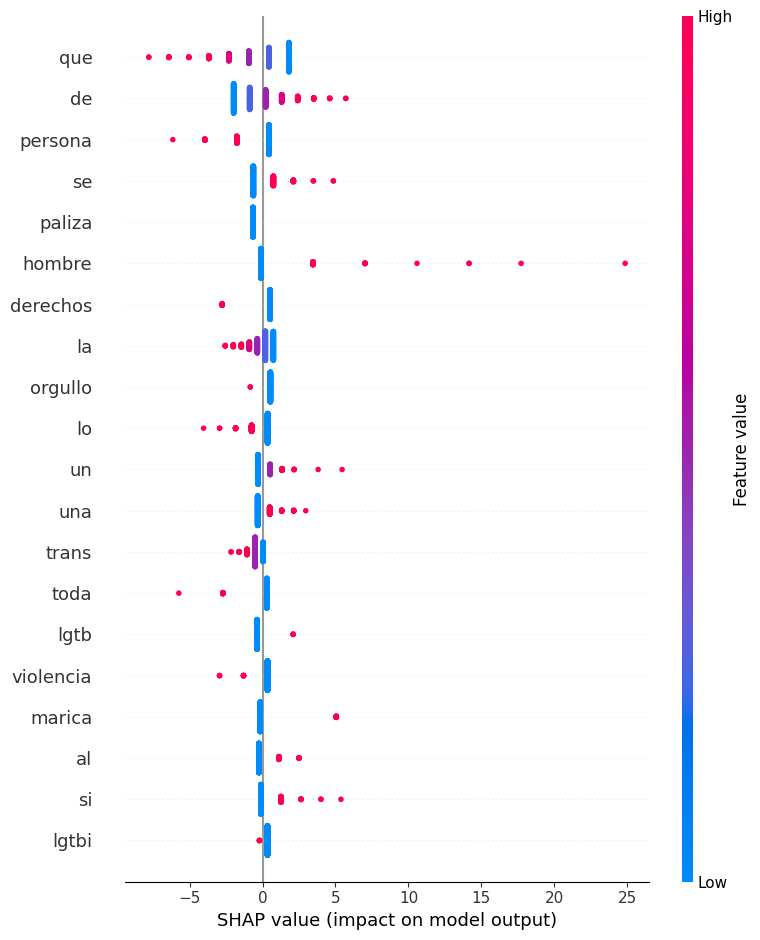

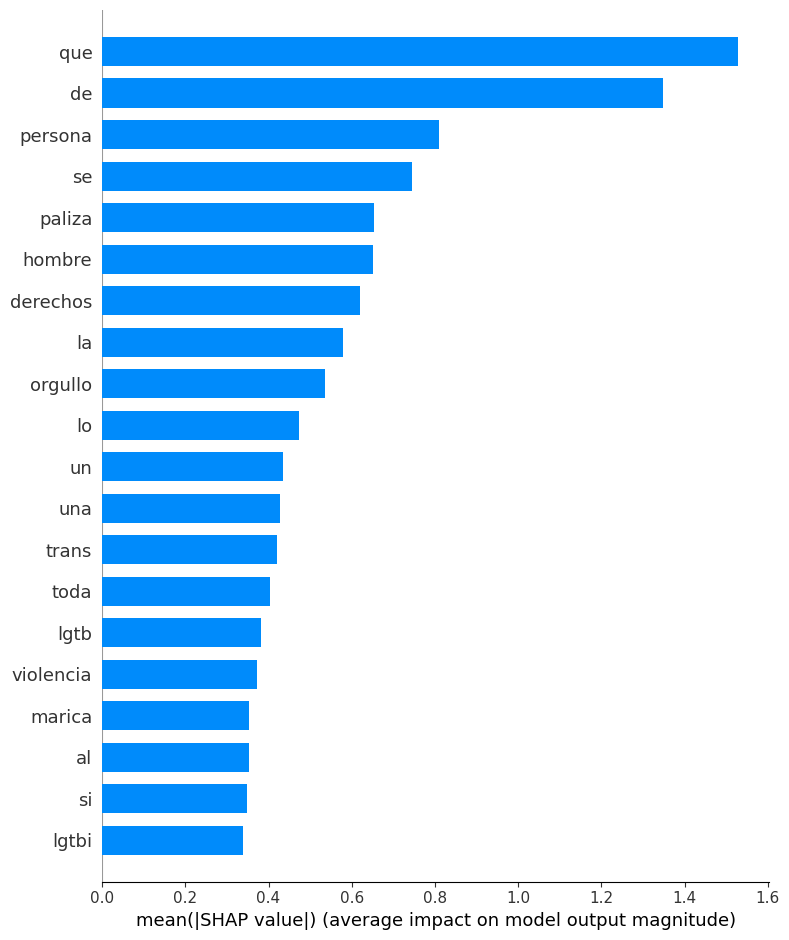

In [ ]:
explainer_sgd_bow, shap_values_sgd_bow = explainable_AI(sgd_classifier_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_sgd_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_sgd_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF result:

Accuracy: 0.5759
Precision: 0.5195
Recall: 0.8097
F1-score: 0.6329
Confusion Matrix:
[[115 185]
 [ 47 200]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.38      0.50       300
           1       0.52      0.81      0.63       247

    accuracy                           0.58       547
   macro avg       0.61      0.60      0.57       547
weighted avg       0.62      0.58      0.56       547



Summary plot as a whole:


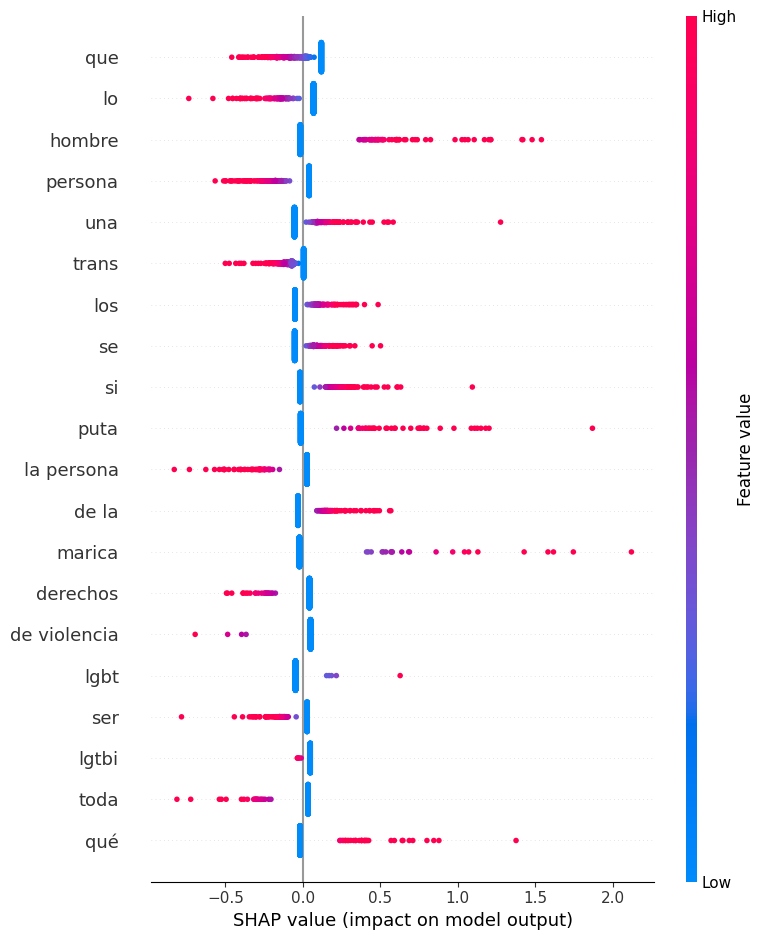

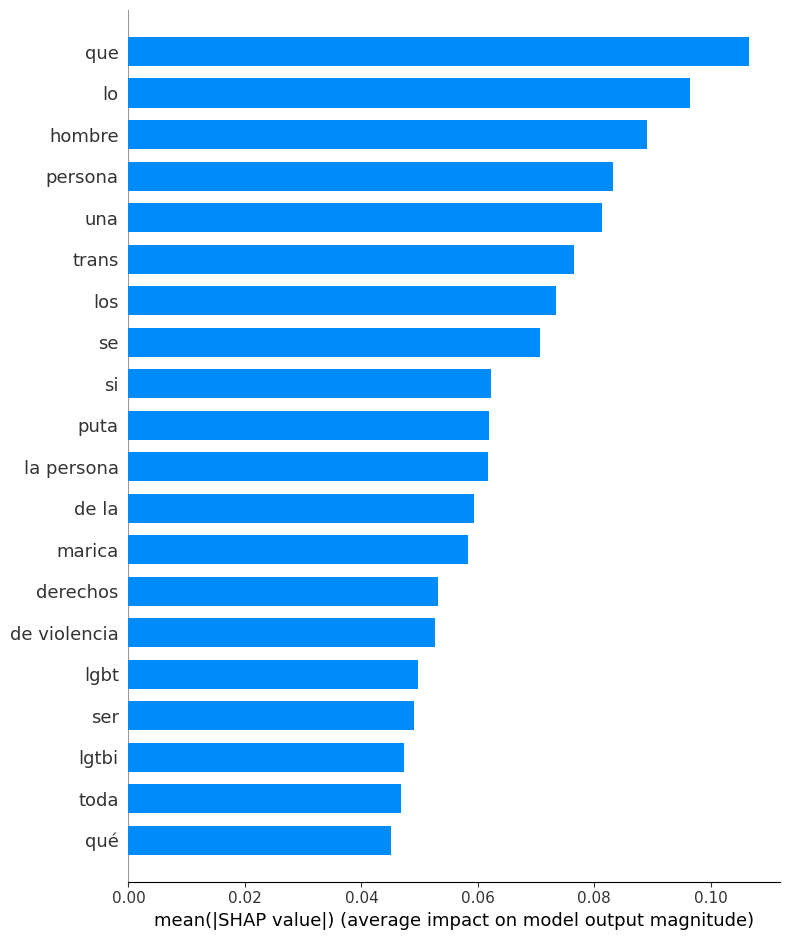

In [ ]:
explainer_sgd_tfidf, shap_values_sgd_tfidf = explainable_AI(sgd_classifier_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Passive Aggressive Classifier

In [ ]:
from sklearn.linear_model import PassiveAggressiveClassifier

# Train Passive Aggressive Classifier model
pa_classifier_model_bow = PassiveAggressiveClassifier(random_state=42)
pa_classifier_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_pa_mybag = pa_classifier_model_bow.predict(X_test_mybag)

In [ ]:
# Train Passive Aggressive Classifier model
pa_classifier_model_tfidf = PassiveAggressiveClassifier(random_state=42)
pa_classifier_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_pa_tfidf = pa_classifier_model_tfidf.predict(X_test_tfidf)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_pa_mybag)
y_test_pa_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_pa_mybag

array([1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_pa_tfidf)
y_test_pa_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_pa_tfidf

array([1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_pa_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_pa_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_pa_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_pa_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_pa_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_pa_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



Bag of words result:

Accuracy: 0.5777
Precision: 0.5220
Recall: 0.7692
F1-score: 0.6219
Confusion Matrix:
[[126 174]
 [ 57 190]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.42      0.52       300
           1       0.52      0.77      0.62       247

    accuracy                           0.58       547
   macro avg       0.61      0.59      0.57       547
weighted avg       0.61      0.58      0.57       547



Summary plot as a whole:


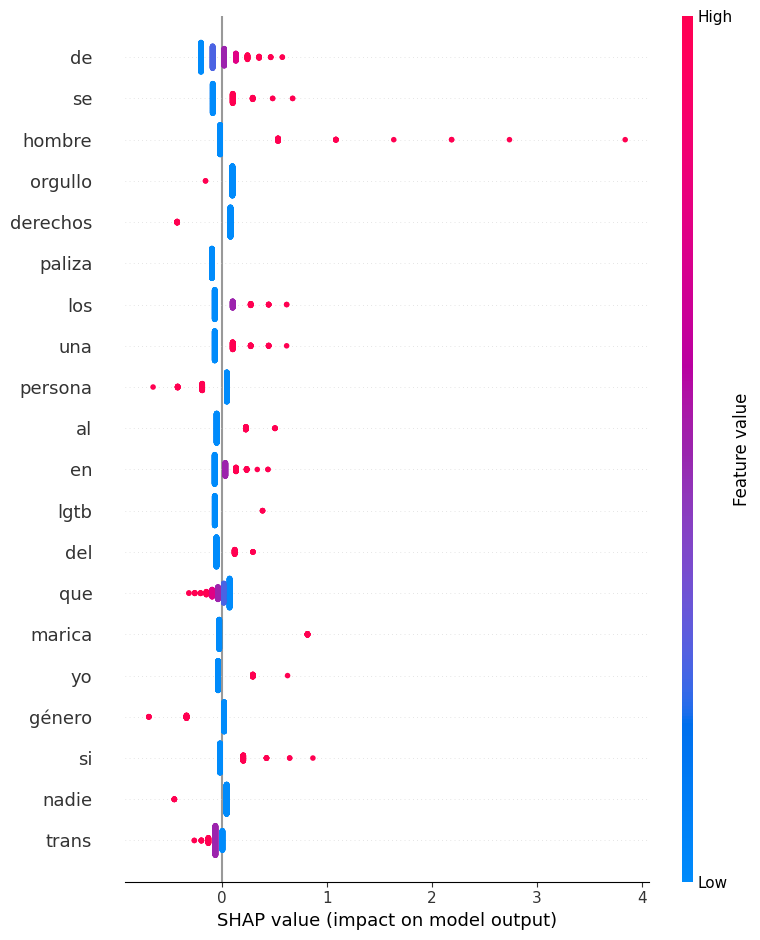

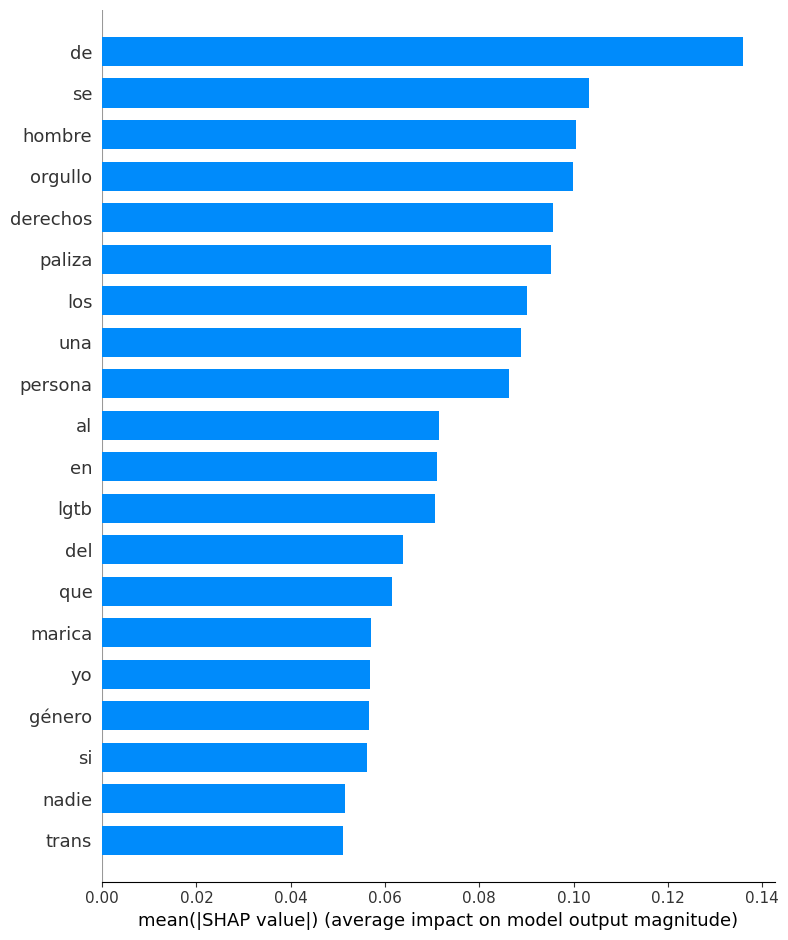

In [ ]:
explainer_pa_bow, shap_values_pa_bow = explainable_AI(pa_classifier_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_pa_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_pa_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_pa_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_pa_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_pa_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_pa_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



TFIDF result:

Accuracy: 0.5704
Precision: 0.5155
Recall: 0.8057
F1-score: 0.6288
Confusion Matrix:
[[113 187]
 [ 48 199]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.38      0.49       300
           1       0.52      0.81      0.63       247

    accuracy                           0.57       547
   macro avg       0.61      0.59      0.56       547
weighted avg       0.62      0.57      0.55       547



Summary plot as a whole:


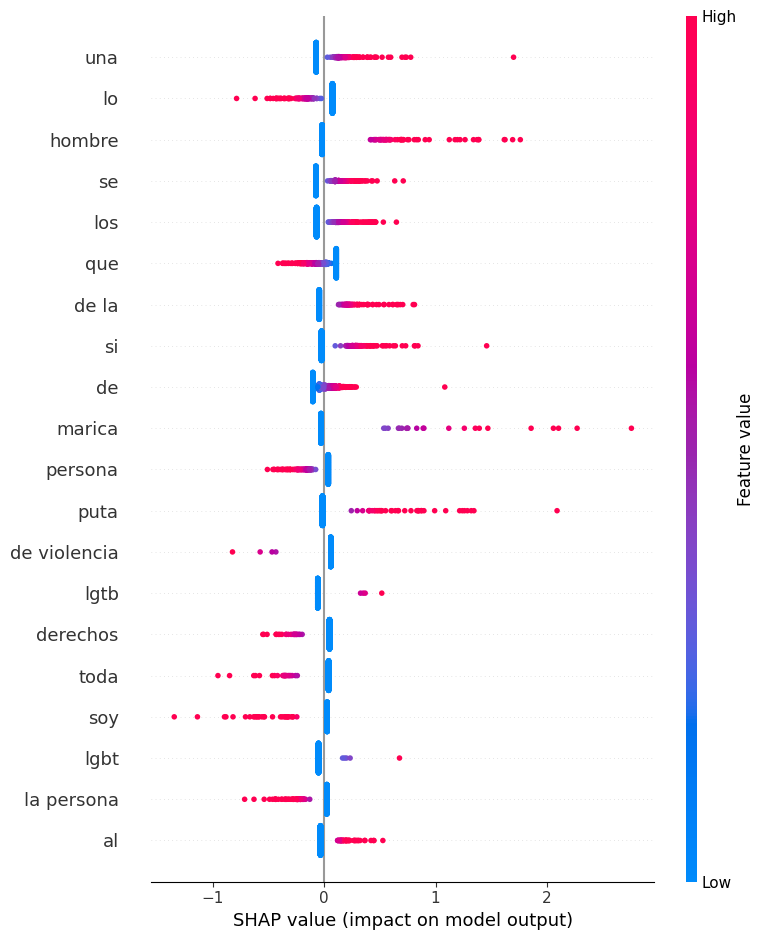

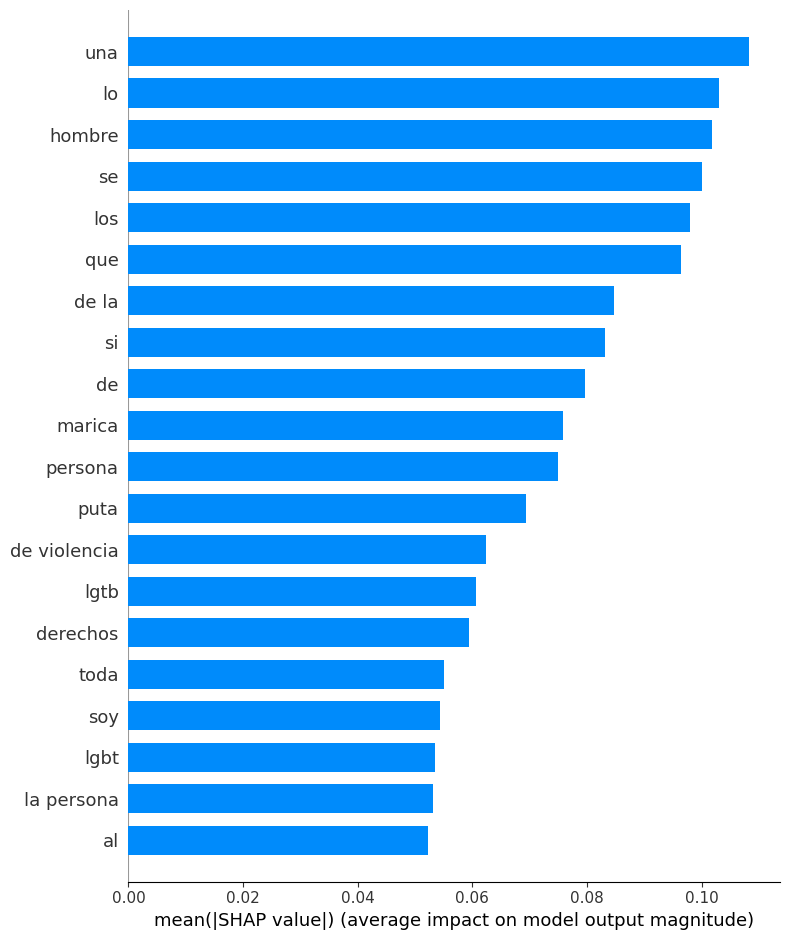

In [ ]:
explainer_pa_tfidf, shap_values_pa_tfidf = explainable_AI(pa_classifier_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Deep Learning Models

# CNN

In [ ]:
pip install tensorflow

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd

# Assuming df_test_labels contains the true labels for the test set
df_test_labels = pd.read_csv("/content/spanish/hope_spanish_test_with_labels.csv", index_col=0)
y_true = df_test_labels['category']

# Tokenize and pad sequences
max_words = 10000
max_len = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Create a LabelEncoder and fit on the true labels
encoder = LabelEncoder()
encoder_2 = LabelEncoder()
y_train_encoded = encoder_2.fit_transform(y_train)
encoder.fit(y_true)

# Build CNN model
model = Sequential()
model.add(Embedding(max_words, 50, input_length=max_len))
model.add(Conv1D(128, 5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

# Convert true labels to numeric values
y_true_numeric = encoder.transform(y_true)

# Predict on the test set
y_test_probabilities = model.predict(X_test_pad)
y_test_predicted_labels_cnn = (y_test_probabilities > 0.5).astype(int)

# Convert predicted labels back to original labels
y_test_predicted_labels_cnn_str = encoder.inverse_transform(y_test_predicted_labels_cnn.flatten())

# Evaluate the model
accuracy_cnn = accuracy_score(y_true_numeric, y_test_predicted_labels_cnn)
precision_cnn = precision_score(y_true_numeric, y_test_predicted_labels_cnn, average='weighted', zero_division=0)
recall_cnn = recall_score(y_true_numeric, y_test_predicted_labels_cnn, average='weighted', zero_division=0)
f1_cnn = f1_score(y_true_numeric, y_test_predicted_labels_cnn, average='weighted', zero_division=0)

# Print the results
print(f"Accuracy: {accuracy_cnn:.4f}")
print(f"Precision: {precision_cnn:.4f}")
print(f"Recall: {recall_cnn:.4f}")
print(f"F1-score: {f1_cnn:.4f}")


Epoch 1/10
41/41 [==============================] - 3s 30ms/step - loss: 0.6850 - accuracy: 0.5407 - val_loss: 0.6824 - val_accuracy: 0.4489
Epoch 2/10
41/41 [==============================] - 1s 29ms/step - loss: 0.5385 - accuracy: 0.7611 - val_loss: 0.6322 - val_accuracy: 0.6842
Epoch 3/10
41/41 [==============================] - 1s 24ms/step - loss: 0.2137 - accuracy: 0.9387 - val_loss: 0.4307 - val_accuracy: 0.8204
Epoch 4/10
41/41 [==============================] - 1s 27ms/step - loss: 0.0234 - accuracy: 0.9969 - val_loss: 0.5417 - val_accuracy: 0.8050
Epoch 5/10
41/41 [==============================] - 2s 49ms/step - loss: 0.0029 - accuracy: 1.0000 - val_loss: 0.6718 - val_accuracy: 0.7740
Epoch 6/10
41/41 [==============================] - 2s 52ms/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.6793 - val_accuracy: 0.7833
Epoch 7/10
41/41 [==============================] - 3s 63ms/step - loss: 6.7862e-04 - accuracy: 1.0000 - val_loss: 0.7098 - val_accuracy: 0.7802
Epoch 8/1

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_cnn)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_cnn)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[131 169]
 [ 55 192]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.44      0.54       300
           1       0.53      0.78      0.63       247

    accuracy                           0.59       547
   macro avg       0.62      0.61      0.59       547
weighted avg       0.63      0.59      0.58       547



PermutationExplainer explainer: 548it [2:20:00, 15.36s/it]


Summary plot as a whole:


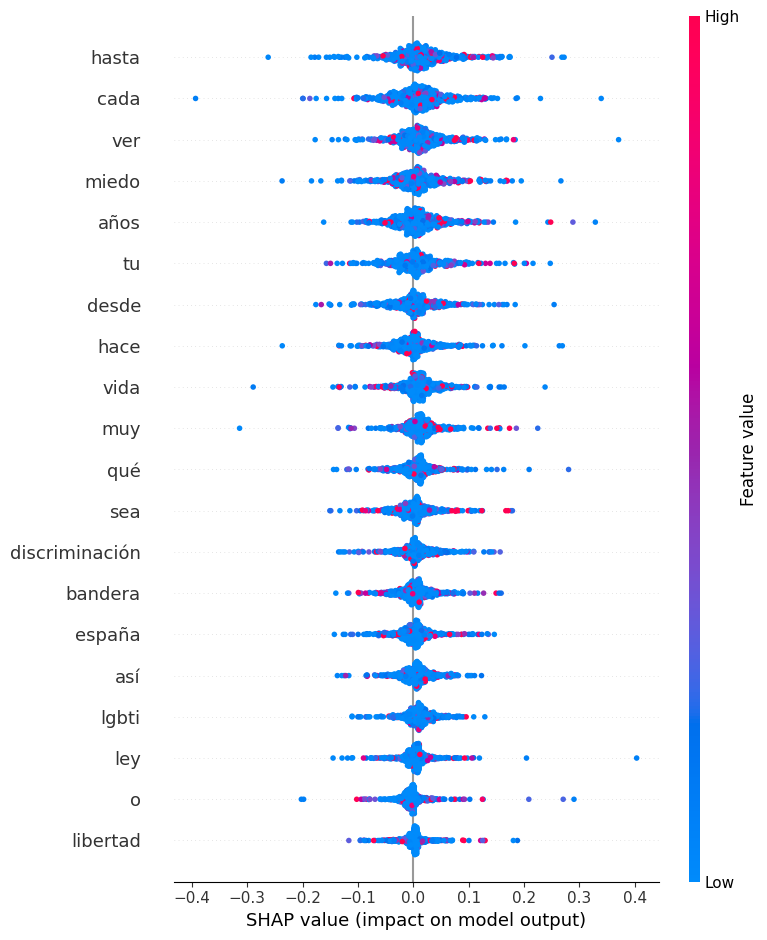

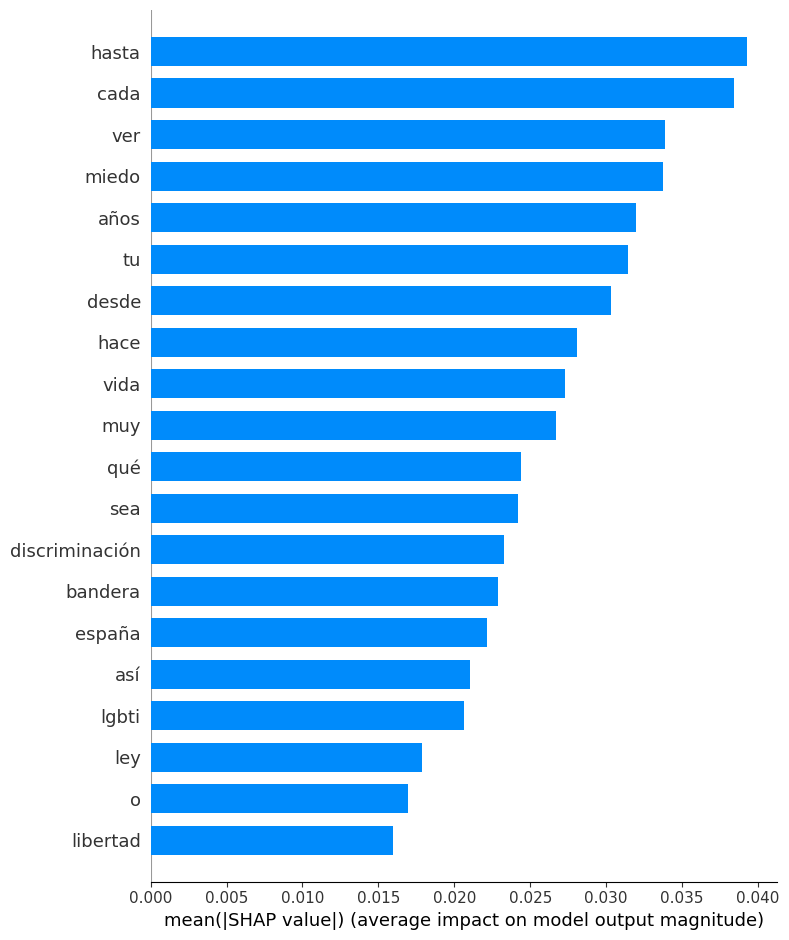

In [ ]:
explainer_cnn, shap_values_cnn = explainable_AI(model,X_train_pad,list(ALL_WORDS),X_test_pad,shap.Explainer,False)

# LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize and pad sequences
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# Define the LSTM model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
# model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, return_sequences=True))  # Add return_sequences=True for stacking LSTM layers
# model.add(Dropout(0.2))  # Dropout for regularization
model.add(LSTM(100))
# model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))  # Additional dense layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train_seq, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
y_test_prob = model.predict(X_test_seq)
y_test_pred = (y_test_prob > 0.5).astype(int)

# Convert y_true to numeric values
y_true_numeric = encoder.transform(y_true)

# Evaluate the model
accuracy_lstm = accuracy_score(y_true_numeric, y_test_pred)
precision_lstm = precision_score(y_true_numeric, y_test_pred, average='weighted', zero_division=0)
recall_lstm = recall_score(y_true_numeric, y_test_pred, average='weighted', zero_division=0)
f1_lstm = f1_score(y_true_numeric, y_test_pred, average='weighted', zero_division=0)

# Print the evaluation metrics
print(f"Accuracy: {accuracy_lstm:.4f}")
print(f"Precision: {precision_lstm:.4f}")
print(f"Recall: {recall_lstm:.4f}")
print(f"F1 Score: {f1_lstm:.4f}")


Epoch 1/10
41/41 [==============================] - 32s 552ms/step - loss: 0.6108 - accuracy: 0.6323 - val_loss: 0.6743 - val_accuracy: 0.6966
Epoch 2/10
41/41 [==============================] - 15s 352ms/step - loss: 0.2698 - accuracy: 0.9007 - val_loss: 0.5709 - val_accuracy: 0.7461
Epoch 3/10
41/41 [==============================] - 10s 238ms/step - loss: 0.0542 - accuracy: 0.9829 - val_loss: 0.5825 - val_accuracy: 0.8080
Epoch 4/10
41/41 [==============================] - 11s 266ms/step - loss: 0.0095 - accuracy: 0.9984 - val_loss: 1.4453 - val_accuracy: 0.6842
Epoch 5/10
41/41 [==============================] - 11s 258ms/step - loss: 0.0042 - accuracy: 0.9984 - val_loss: 1.9944 - val_accuracy: 0.6563
Epoch 6/10
41/41 [==============================] - 17s 426ms/step - loss: 0.0017 - accuracy: 0.9992 - val_loss: 1.2273 - val_accuracy: 0.7709
Epoch 7/10
41/41 [==============================] - 21s 524ms/step - loss: 1.6263e-04 - accuracy: 1.0000 - val_loss: 1.4237 - val_accuracy: 0.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_pred)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_pred)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[135 165]
 [ 47 200]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.45      0.56       300
           1       0.55      0.81      0.65       247

    accuracy                           0.61       547
   macro avg       0.64      0.63      0.61       547
weighted avg       0.65      0.61      0.60       547



# Bi-LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize and pad sequences
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# Define the bi-LSTM model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
# model.add(SpatialDropout1D(0.2))
model.add(Bidirectional(LSTM(100)))
model.add(Dense(64, activation='relu'))  # Additional dense layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train_seq, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
y_test_prob_bilstm = model.predict(X_test_seq)
y_test_pred_bilstm = (y_test_prob > 0.5).astype(int)

# Convert y_true to numeric values
y_true_numeric = encoder.transform(y_true)

# Evaluate the model
accuracy_bilstm = accuracy_score(y_true_numeric, y_test_pred_bilstm)
precision_bilstm = precision_score(y_true_numeric, y_test_pred_bilstm, average='weighted', zero_division=0)
recall_bilstm = recall_score(y_true_numeric, y_test_pred_bilstm, average='weighted', zero_division=0)
f1_bilstm = f1_score(y_true_numeric, y_test_pred_bilstm, average='weighted', zero_division=0)

# Print the evaluation metrics
print(f"Accuracy: {accuracy_bilstm:.4f}")
print(f"Precision: {precision_bilstm:.4f}")
print(f"Recall: {recall_bilstm:.4f}")
print(f"F1 Score: {f1_bilstm:.4f}")


Epoch 1/10
41/41 [==============================] - 18s 304ms/step - loss: 0.6299 - accuracy: 0.6168 - val_loss: 0.8135 - val_accuracy: 0.6842
Epoch 2/10
41/41 [==============================] - 13s 304ms/step - loss: 0.3061 - accuracy: 0.8937 - val_loss: 0.5824 - val_accuracy: 0.7585
Epoch 3/10
41/41 [==============================] - 12s 303ms/step - loss: 0.0825 - accuracy: 0.9697 - val_loss: 0.5013 - val_accuracy: 0.8328
Epoch 4/10
41/41 [==============================] - 12s 303ms/step - loss: 0.0184 - accuracy: 0.9953 - val_loss: 0.8006 - val_accuracy: 0.8019
Epoch 5/10
41/41 [==============================] - 12s 302ms/step - loss: 0.0074 - accuracy: 0.9992 - val_loss: 1.1138 - val_accuracy: 0.7554
Epoch 6/10
41/41 [==============================] - 10s 246ms/step - loss: 0.0017 - accuracy: 1.0000 - val_loss: 0.9093 - val_accuracy: 0.7740
Epoch 7/10
41/41 [==============================] - 13s 326ms/step - loss: 4.5333e-04 - accuracy: 1.0000 - val_loss: 1.1001 - val_accuracy: 0.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_pred_bilstm)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_pred_bilstm)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[135 165]
 [ 47 200]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.45      0.56       300
           1       0.55      0.81      0.65       247

    accuracy                           0.61       547
   macro avg       0.64      0.63      0.61       547
weighted avg       0.65      0.61      0.60       547



# Simple RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# Define the RNN model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(SimpleRNN(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
model.fit(X_train_padded, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Predict on the test set
y_pred_rnn = (model.predict(X_test_padded) > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_pred_rnn)
precision = precision_score(y_true_numeric, y_pred_rnn, average='binary')
recall = recall_score(y_true_numeric, y_pred_rnn, average='binary')
f1 = f1_score(y_true_numeric, y_pred_rnn, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/5
21/21 [==============================] - 3s 78ms/step - loss: 0.6820 - accuracy: 0.5981 - val_loss: 0.6688 - val_accuracy: 0.7276
Epoch 2/5
21/21 [==============================] - 1s 61ms/step - loss: 0.6218 - accuracy: 0.7432 - val_loss: 0.6587 - val_accuracy: 0.6563
Epoch 3/5
21/21 [==============================] - 1s 58ms/step - loss: 0.4860 - accuracy: 0.8472 - val_loss: 0.5462 - val_accuracy: 0.7152
Epoch 4/5
21/21 [==============================] - 2s 95ms/step - loss: 0.2649 - accuracy: 0.9232 - val_loss: 0.4930 - val_accuracy: 0.7616
Epoch 5/5
18/18 [==============================] - 0s 10ms/step
Accuracy: 0.6088
Precision: 0.5579
Recall: 0.6437
F1-score: 0.5977


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_pred_rnn)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_pred_rnn)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[174 126]
 [ 88 159]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.58      0.62       300
           1       0.56      0.64      0.60       247

    accuracy                           0.61       547
   macro avg       0.61      0.61      0.61       547
weighted avg       0.62      0.61      0.61       547



# DNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# Define the DNN model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Predict on the test set
y_pred_dnn = (model.predict(X_test_padded) > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_pred_dnn)
precision = precision_score(y_true_numeric, y_pred_dnn, average='binary')
recall = recall_score(y_true_numeric, y_pred_dnn, average='binary')
f1 = f1_score(y_true_numeric, y_pred_dnn, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
21/21 [==============================] - 6s 182ms/step - loss: 0.7060 - accuracy: 0.5066 - val_loss: 0.6740 - val_accuracy: 0.6904
Epoch 2/10
21/21 [==============================] - 5s 230ms/step - loss: 0.6855 - accuracy: 0.5384 - val_loss: 0.7090 - val_accuracy: 0.3127
Epoch 3/10
21/21 [==============================] - 3s 159ms/step - loss: 0.6524 - accuracy: 0.6168 - val_loss: 0.6278 - val_accuracy: 0.7214
Epoch 4/10
21/21 [==============================] - 3s 147ms/step - loss: 0.3971 - accuracy: 0.8735 - val_loss: 0.5011 - val_accuracy: 0.7895
Epoch 5/10
21/21 [==============================] - 3s 139ms/step - loss: 0.0616 - accuracy: 0.9798 - val_loss: 0.7542 - val_accuracy: 0.7492
Epoch 6/10
21/21 [==============================] - 3s 129ms/step - loss: 0.0059 - accuracy: 1.0000 - val_loss: 0.7006 - val_accuracy: 0.7926
Epoch 7/10
21/21 [==============================] - 3s 162ms/step - loss: 0.0022 - accuracy: 1.0000 - val_loss: 0.8377 - val_accuracy: 0.7802
Epoch 

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_pred_dnn)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_pred_dnn)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[112 188]
 [ 39 208]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.37      0.50       300
           1       0.53      0.84      0.65       247

    accuracy                           0.59       547
   macro avg       0.63      0.61      0.57       547
weighted avg       0.64      0.59      0.56       547



PermutationExplainer explainer: 548it [1:40:31, 11.03s/it]


Summary plot as a whole:


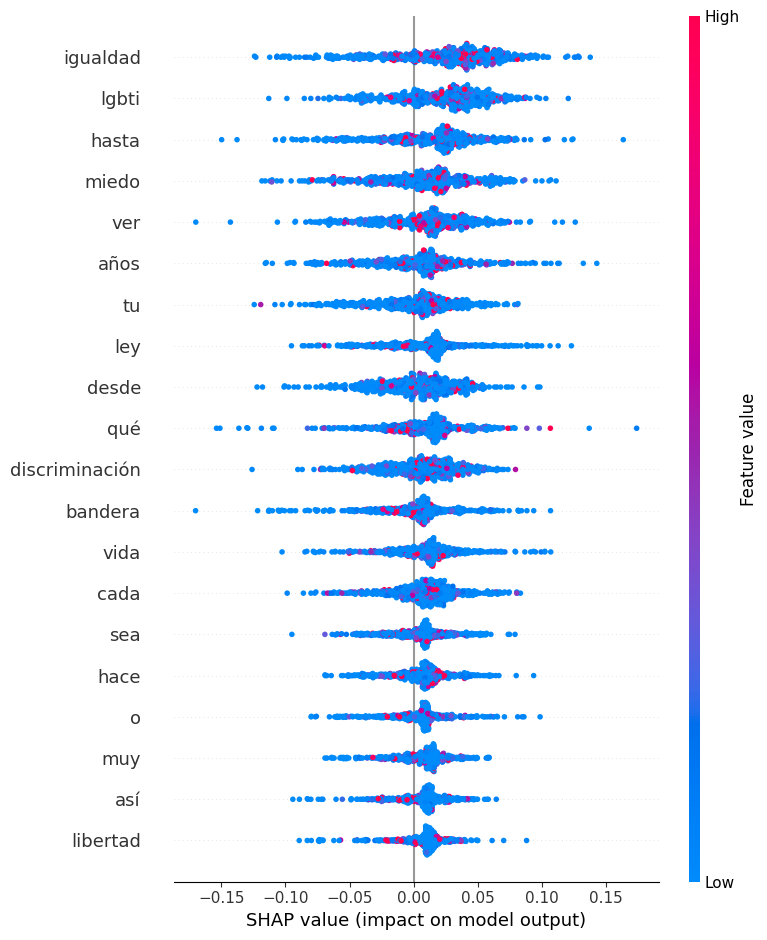

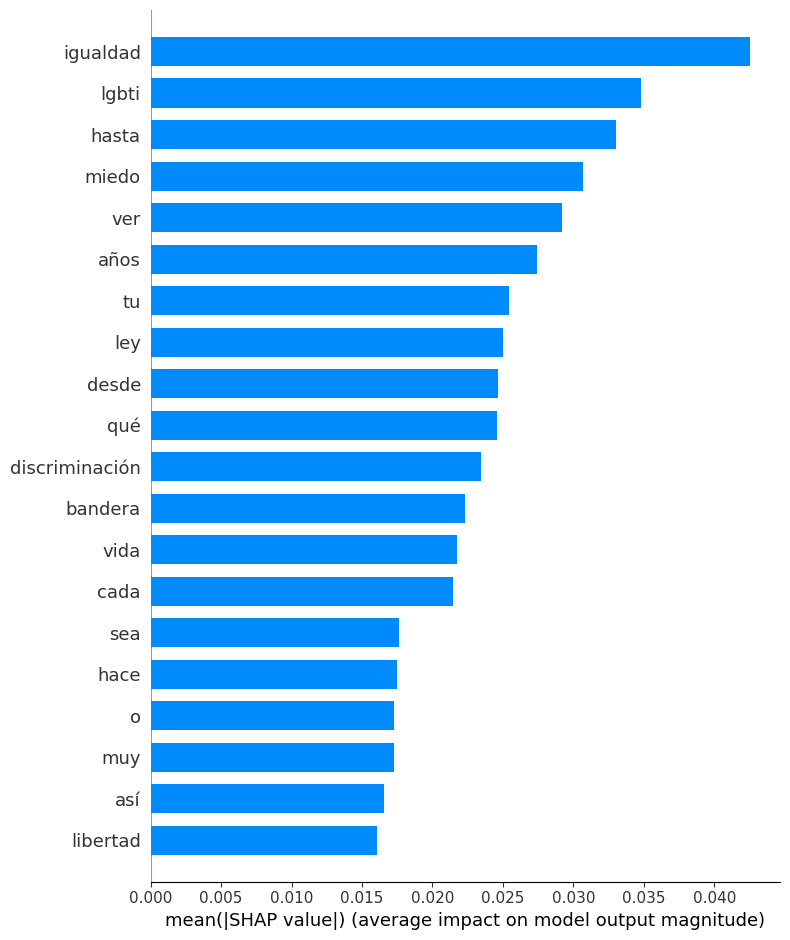

In [ ]:
explainer_dnn, shap_values_dnn = explainable_AI(model,X_train_padded,list(ALL_WORDS),X_test_padded,shap.Explainer,False)

# DNN + Embeddings

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# Define the DNN+Embedding model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Predict on the test set
y_pred_dnn_emb = (model.predict(X_test_padded) > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_pred_dnn_emb)
precision = precision_score(y_true_numeric, y_pred_dnn_emb, average='binary')
recall = recall_score(y_true_numeric, y_pred_dnn_emb, average='binary')
f1 = f1_score(y_true_numeric, y_pred_dnn_emb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
21/21 [==============================] - 4s 100ms/step - loss: 0.7030 - accuracy: 0.5299 - val_loss: 0.6764 - val_accuracy: 0.6904
Epoch 2/10
21/21 [==============================] - 2s 103ms/step - loss: 0.6844 - accuracy: 0.5555 - val_loss: 0.7388 - val_accuracy: 0.3096
Epoch 3/10
21/21 [==============================] - 2s 110ms/step - loss: 0.6456 - accuracy: 0.6284 - val_loss: 0.6349 - val_accuracy: 0.7461
Epoch 4/10
21/21 [==============================] - 2s 119ms/step - loss: 0.4104 - accuracy: 0.8821 - val_loss: 0.6481 - val_accuracy: 0.6997
Epoch 5/10
21/21 [==============================] - 3s 165ms/step - loss: 0.0702 - accuracy: 0.9837 - val_loss: 0.7386 - val_accuracy: 0.7523
Epoch 6/10
21/21 [==============================] - 3s 159ms/step - loss: 0.0071 - accuracy: 0.9984 - val_loss: 0.8718 - val_accuracy: 0.7585
Epoch 7/10
21/21 [==============================] - 3s 156ms/step - loss: 0.0033 - accuracy: 0.9984 - val_loss: 0.9354 - val_accuracy: 0.7368
Epoch 

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_pred_dnn_emb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_pred_dnn_emb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[175 125]
 [ 80 167]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.58      0.63       300
           1       0.57      0.68      0.62       247

    accuracy                           0.63       547
   macro avg       0.63      0.63      0.63       547
weighted avg       0.63      0.63      0.63       547



PermutationExplainer explainer: 548it [1:39:54, 10.96s/it]


Summary plot as a whole:


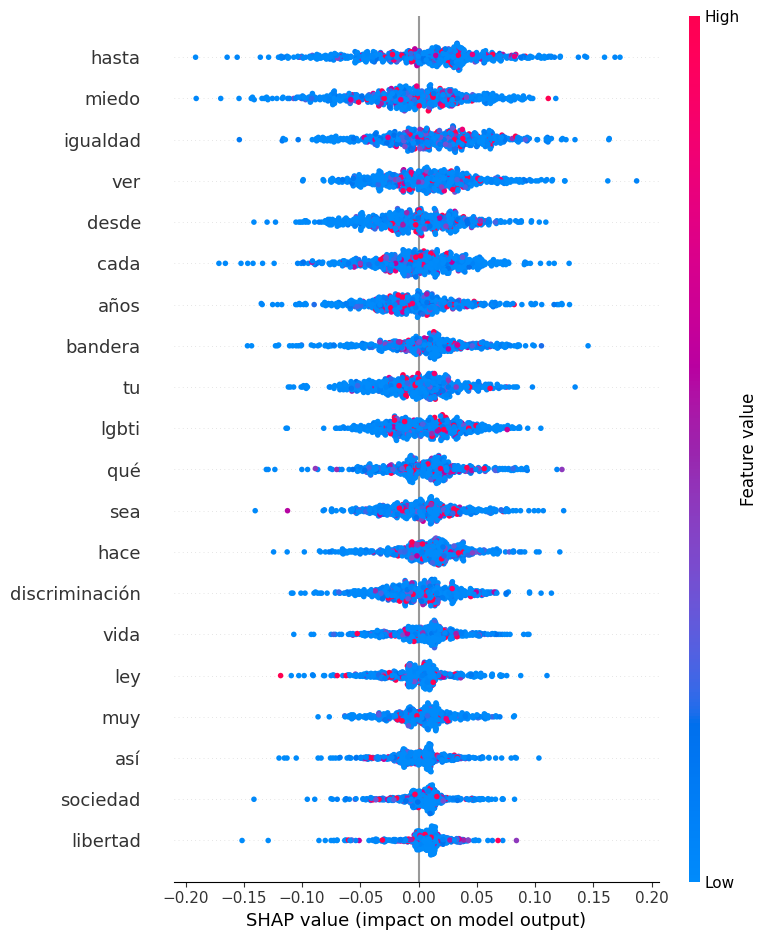

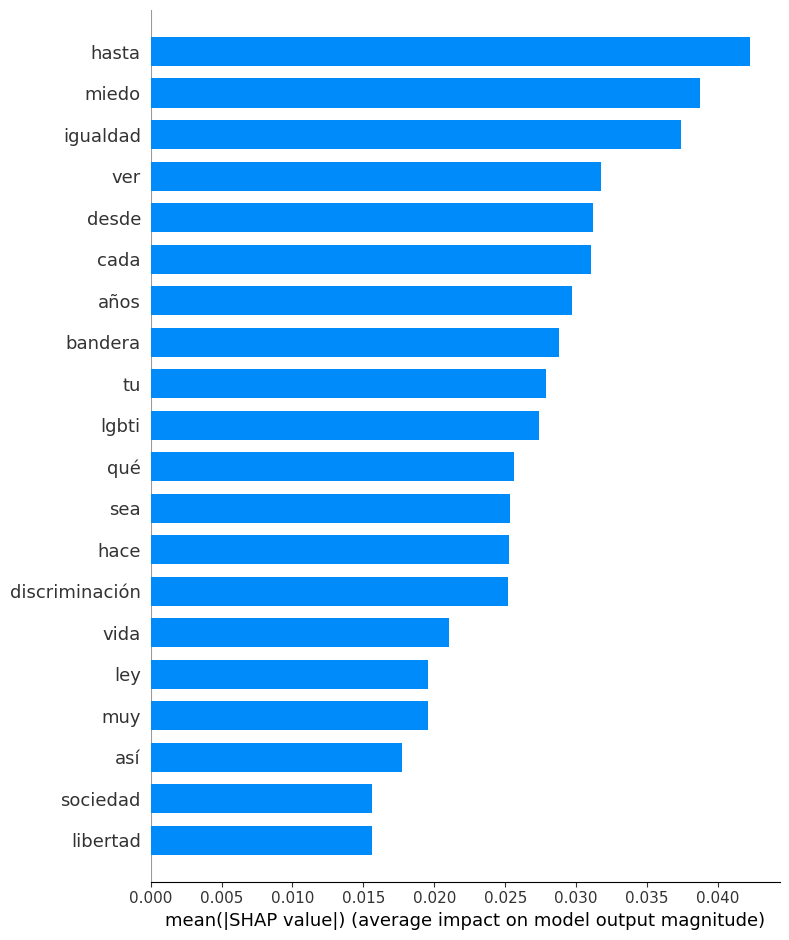

In [ ]:
explainer_dnn_emb, shap_values_dnn_emb = explainable_AI(model,X_train_padded,list(ALL_WORDS),X_test_padded,shap.Explainer,False)

# Gated Recurrence Unit(GRU)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# # Build GRU model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(GRU(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# # Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Train the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=32, validation_split=0.2)

# # Predict on the test set
y_test_predicted_labels = (model.predict(X_test_padded) > 0.5).astype(int)

# # Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels)
precision = precision_score(y_true_numeric, y_test_predicted_labels, average='binary')
recall = recall_score(y_true_numeric, y_test_predicted_labels, average='binary')
f1 = f1_score(y_true_numeric, y_test_predicted_labels, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
41/41 [==============================] - 17s 305ms/step - loss: 0.6651 - accuracy: 0.5663 - val_loss: 0.5988 - val_accuracy: 0.7740
Epoch 2/10
41/41 [==============================] - 12s 301ms/step - loss: 0.4449 - accuracy: 0.8270 - val_loss: 0.6191 - val_accuracy: 0.7276
Epoch 3/10
41/41 [==============================] - 13s 312ms/step - loss: 0.1312 - accuracy: 0.9573 - val_loss: 0.5002 - val_accuracy: 0.8050
Epoch 4/10
41/41 [==============================] - 14s 335ms/step - loss: 0.0462 - accuracy: 0.9899 - val_loss: 0.8483 - val_accuracy: 0.7554
Epoch 5/10
41/41 [==============================] - 12s 305ms/step - loss: 0.0757 - accuracy: 0.9791 - val_loss: 0.7385 - val_accuracy: 0.7337
Epoch 6/10
41/41 [==============================] - 14s 354ms/step - loss: 0.0214 - accuracy: 0.9938 - val_loss: 1.8079 - val_accuracy: 0.6904
Epoch 7/10
41/41 [==============================] - 10s 247ms/step - loss: 0.0059 - accuracy: 0.9984 - val_loss: 2.2142 - val_accuracy: 0.6594

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[132 168]
 [ 45 202]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.44      0.55       300
           1       0.55      0.82      0.65       247

    accuracy                           0.61       547
   macro avg       0.65      0.63      0.60       547
weighted avg       0.66      0.61      0.60       547

